<a href="https://colab.research.google.com/github/RR77ui/Business-Intelligence/blob/main/Aprendizaje%20Supervisado/Regresiones_y_ARD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. Importar las librerias

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Cargar los datos, analizar los datos, transformarlos y matriz de correlacion

In [ ]:
path='/content/drive/MyDrive/Aprendizaje Supervisado/wage_dataset.csv'
df=pd.read_csv(path)
df.head()


# Educacion como una variable ordinal dando mayor peso a quien mas ha estudiado
education_mapping = {'<HS': 1, 'HS': 2, 'SomeCollege': 3, 'College': 4, 'Advanced': 5}
df['education'] = df['education'].map(education_mapping)

df = pd.get_dummies(df, columns=['jobclass', 'region'], prefix=['jobclass', 'region'], dtype=int)
df = df.dropna()

# mirar que si quedaron los datos como enteros
print(df.dtypes)

# Matriz de correlacion
numeric_df = df.select_dtypes(include=np.number)
display(numeric_df.corr())
display(df.describe())
df.shape

age                     int64
education               int64
experience              int64
salary                  int64
jobclass_Industrial     int64
jobclass_Information    int64
region_East             int64
region_South            int64
region_West             int64
dtype: object


,age,education,experience,salary,jobclass_Industrial,jobclass_Information,region_East,region_South,region_West
age,1.000000,-0.007157,0.015108,-0.037266,0.034695,-0.034695,0.018810,-0.019879,0.000893
education,-0.007157,1.000000,0.010110,-0.020155,-0.004823,0.004823,0.022442,-0.016419,-0.006165
experience,0.015108,0.010110,1.000000,0.022696,0.007693,-0.007693,-0.005032,0.036848,-0.031474
salary,-0.037266,-0.020155,0.022696,1.000000,0.019928,-0.019928,0.003536,-0.032169,0.028334
jobclass_Industrial,0.034695,-0.004823,0.007693,0.019928,1.000000,-1.000000,0.047397,-0.004895,-0.042525
jobclass_Information,-0.034695,0.004823,-0.007693,-0.019928,-1.000000,1.000000,-0.047397,0.004895,0.042525
region_East,0.018810,0.022442,-0.005032,0.003536,0.047397,-0.047397,1.000000,-0.495083,-0.509054
region_South,-0.019879,-0.016419,0.036848,-0.032169,-0.004895,0.004895,-0.495083,1.000000,-0.495822
region_West,0.000893,-0.006165,-0.031474,0.028334,-0.042525,0.042525,-0.509054,-0.495822,1.000000


,age,education,experience,salary,jobclass_Industrial,jobclass_Information,region_East,region_South,region_West
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,41.149000,2.931000,19.495333,50056.518333,0.414333,0.585667,0.337000,0.325333,0.337667
std,13.474989,1.155285,11.462712,15196.908663,0.492689,0.492689,0.472764,0.468577,0.472993
min,18.000000,1.000000,0.000000,-479.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,10.000000,39780.750000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,41.000000,3.000000,19.000000,49860.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,53.000000,4.000000,29.000000,60458.750000,1.000000,1.000000,1.000000,1.000000,1.000000
max,64.000000,5.000000,39.000000,101279.000000,1.000000,1.000000,1.000000,1.000000,1.000000


(3000, 9)

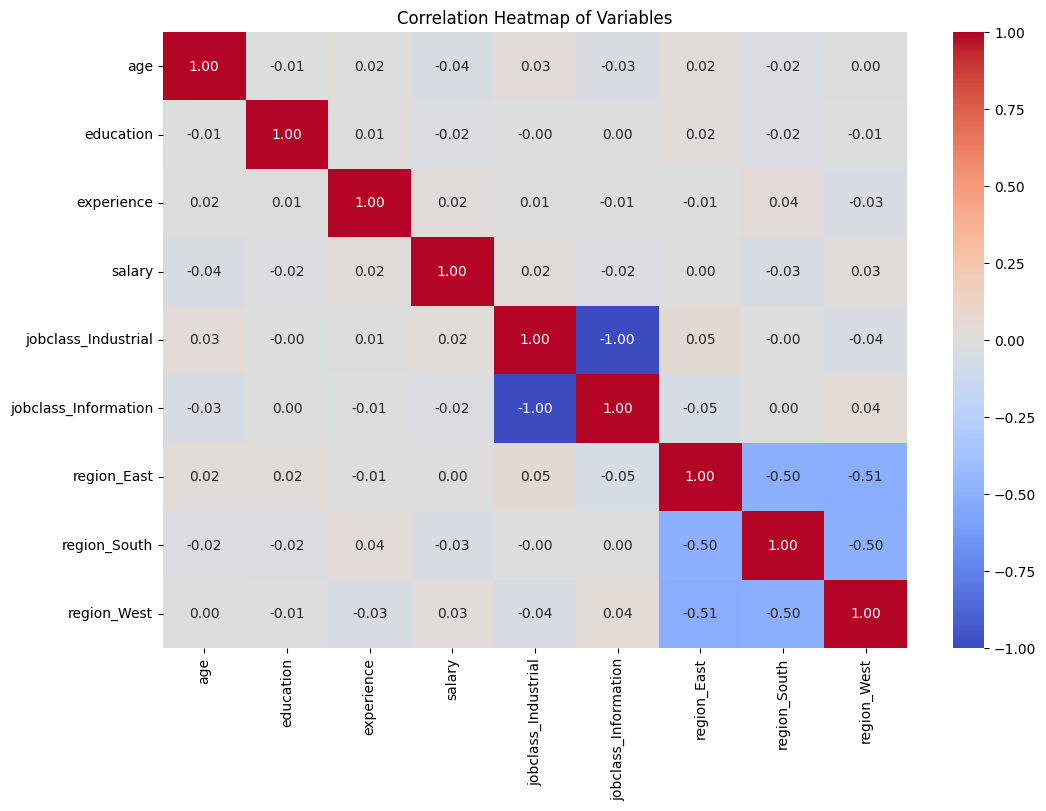

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'numeric_df' from the previous cell contains the numeric data for correlation
# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Variables')
plt.show()

2. Particion de los datos

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df is the DataFrame after all preprocessing steps (including one-hot encoding)
X = df.drop(['salary'], axis=1)
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
# Para usar las variables de la regresión, estas deben ser tipo array
#X = np.array(X_train) # No need to convert to numpy array for LinearRegression
#Y = np.array(y_train).reshape(-1, 1) # No need to convert to numpy array for LinearRegression

# Modelo de regresión
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Ver coeficientes
print("Intercepto (a):", modelo.intercept_)

# Print coefficients with variable names
print("Coeficientes (b):")
for i, col in enumerate(X_train.columns):
    print(f"{col}: {modelo.coef_[i]}")

Intercepto (a): 51207.142782052004
Coeficientes (b):
age: -45.66389824682111
education: -127.73340156453041
experience: 42.60344153484402
jobclass_Industrial: 155.61001185056574
jobclass_Information: -155.61001185056674
region_East: -153.256880930855
region_South: -868.2382248341619
region_West: 1021.495105765019


3. Modelo de regresion Simple

In [ ]:
import statsmodels.api as sm

# Intercepto
X_const = sm.add_constant(X_train)

# Modelo de regresión
modelo_sm = sm.OLS(y_train, X_const).fit()

# Imprimir el resumen del modelo (incluye la ecuación y ANOVA)
print(modelo_sm.summary())

# Obtener y mostrar los residuales
residuales = modelo_sm.resid
print("\nResiduales:")
print(residuales)

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.796
Date:                Thu, 18 Sep 2025   Prob (F-statistic):             0.0962
Time:                        15:55:16   Log-Likelihood:                -23226.
No. Observations:                2100   AIC:                         4.647e+04
Df Residuals:                    2093   BIC:                         4.651e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2.793e+04 

3.Modelo de regresion Forward

In [ ]:
#Este es el metodo que vamos a utilizar siempre
from sklearn.linear_model import LinearRegression
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.datasets import make_regression
import statsmodels.api as sm

# Modelo base
lr = LinearRegression()

# Forward selection
sfs = SFS(lr,
          k_features='best',   # Puede ser número fijo o 'best'
          forward=False,        # True = forward, False = backward
          floating=False,      # True para stepwise mixto
          scoring='r2',
          cv=5)

sfs = sfs.fit(X_train, y_train)

print("Variables seleccionadas usando SequentialFeatureSelector (Forward):", sfs.k_feature_names_)

# Crear y ajustar el modelo OLS con las variables seleccionadas
X_train_selected = sm.add_constant(X_train[list(sfs.k_feature_names_)])
model_sfs = sm.OLS(y_train, X_train_selected).fit()

# Resumen del modelo OLS
print("\nResumen del modelo OLS con variables seleccionadas por SequentialFeatureSelector:")
print(model_sfs.summary())

Variables seleccionadas usando SequentialFeatureSelector (Forward): ('region_West',)

Resumen del modelo OLS con variables seleccionadas por SequentialFeatureSelector:
                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.560
Date:                Thu, 18 Sep 2025   Prob (F-statistic):             0.0328
Time:                        15:28:06   Log-Likelihood:                -23229.
No. Observations:                2100   AIC:                         4.646e+04
Df Residuals:                    2098   BIC:                         4.647e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err         

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict on the test set
# Select only the columns used for training from the test set before adding the constant
X_test_selected = sm.add_constant(X_test[list(sfs.k_feature_names_)])
y_pred = model_sfs.predict(X_test_selected)

# Calculate metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Calculate Adjusted R2
n = X_test.shape[0]  # Number of observations
p = X_test_selected.shape[1] - 1 # Number of features (excluding the constant)
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Calculate MAPE (add a small epsilon to prevent division by zero)
epsilon = 1e-10
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100


print("--- Linear Regression Model Metrics (Test Set) ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")
print(f"Adjusted R2: {adjusted_r2:.2f}")
print(f"MAPE: {mape:.2f}%")

--- Linear Regression Model Metrics (Test Set) ---
RMSE: 14682.61
MAE: 11732.51
R2: -0.01
Adjusted R2: -0.01
MAPE: 28.58%


3. Modelo regularizado

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Define the features (X) and target (y)
# Using all features from X_train and X_test as SFS is not defined
X_train_regularized = X_train
X_test_regularized = X_test

# Add a small epsilon to prevent division by zero in MAPE
epsilon = 1e-10

# Ridge Regression
ridge_model = Ridge(alpha=1.0) # You can tune alpha
ridge_model.fit(X_train_regularized, y_train)
y_pred_ridge = ridge_model.predict(X_test_regularized)

print("--- Ridge Regression ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.2f}")
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / (y_test + epsilon))) * 100
print(f"MAPE: {mape_ridge:.2f}%")
print(f"R2: {r2_score(y_test, y_pred_ridge):.2f}")

# Lasso Regression
lasso_model = Lasso(alpha=1.0) # You can tune alpha
lasso_model.fit(X_train_regularized, y_train)
y_pred_lasso = lasso_model.predict(X_test_regularized)

print("\n--- Lasso Regression ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.2f}")
mape_lasso = np.mean(np.abs((y_test - y_pred_lasso) / (y_test + epsilon))) * 100
print(f"MAPE: {mape_lasso:.2f}%")
print(f"R2: {r2_score(y_test, y_pred_lasso):.2f}")

# Elastic Net Regression
elastic_net_model = ElasticNet(alpha=1.0, l1_ratio=0.5) # You can tune alpha and l1_ratio
elastic_net_model.fit(X_train_regularized, y_train)
y_pred_elastic_net = elastic_net_model.predict(X_test_regularized)

print("\n--- Elastic Net Regression ---")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_elastic_net)):.2f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_elastic_net):.2f}")
mape_elastic_net = np.mean(np.abs((y_test - y_pred_elastic_net) / (y_test + epsilon))) * 100
print(f"MAPE: {mape_elastic_net:.2f}%")
print(f"R2: {r2_score(y_test, y_pred_elastic_net):.2f}")


print("--- Linear Regression Model Metrics (Test Set) ---")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2: {r2:.2f}")
print(f"Adjusted R2: {adjusted_r2:.2f}")
print(f"MAPE: {mape:.2f}%")

--- Ridge Regression ---
RMSE: 14657.53
MAE: 11689.40
MAPE: 28.45%
R2: -0.00

--- Lasso Regression ---
RMSE: 14657.58
MAE: 11689.46
MAPE: 28.45%
R2: -0.00

--- Elastic Net Regression ---
RMSE: 14645.47
MAE: 11679.51
MAPE: 28.43%
R2: -0.00
--- Linear Regression Model Metrics (Test Set) ---
RMSE: 14682.61
MAE: 11732.51
R2: -0.01
Adjusted R2: -0.01
MAPE: 28.58%


In [ ]:
print("\n--- Linear Regression Coefficients ---")
print("Intercept (const):", modelo_sm.params['const'])
for feature, coef in zip(X_train_regularized.columns, modelo_sm.params[1:]):
    print(f"{feature}: {coef:.4f}")

print("\n--- Ridge Regression Coefficients ---")
for feature, coef in zip(X_train_regularized.columns, ridge_model.coef_):
    print(f"{feature}: {coef:.4f}")

print("\n--- Lasso Regression Coefficients ---")
for feature, coef in zip(X_train_regularized.columns, lasso_model.coef_):
    print(f"{feature}: {coef:.4f}")

print("\n--- Elastic Net Regression Coefficients ---")
for feature, coef in zip(X_train_regularized.columns, elastic_net_model.coef_):
    print(f"{feature}: {coef:.4f}")


--- Linear Regression Coefficients ---
Intercept (const): 27931.16879021029
age: -45.6639
education: -127.7334
experience: 42.6034
jobclass_Industrial: 14121.1944
jobclass_Information: 13809.9744
region_East: 9157.1327
region_South: 8442.1514
region_West: 10331.8847

--- Ridge Regression Coefficients ---
age: -45.6639
education: -127.6958
experience: 42.5998
jobclass_Industrial: 155.4323
jobclass_Information: -155.4323
region_East: -153.0285
region_South: -867.0006
region_West: 1020.0292

--- Lasso Regression Coefficients ---
age: -45.6537
education: -126.9965
experience: 42.5879
jobclass_Industrial: 306.9962
jobclass_Information: -0.0000
region_East: -0.0000
region_South: -712.1051
region_West: 1171.5546

--- Elastic Net Regression Coefficients ---
age: -45.5240
education: -95.1222
experience: 40.9412
jobclass_Industrial: 70.9310
jobclass_Information: -70.9314
region_East: -59.0386
region_South: -346.6192
region_West: 406.6558


4. Arbol de decision predictivo

In [ ]:
path='/content/drive/MyDrive/Aprendizaje Supervisado/wage_dataset.csv'
df=pd.read_csv(path)
df.head()

,age,education,experience,jobclass,region,salary
0,56,SomeCollege,9,Industrial,South,76496
1,46,SomeCollege,20,Information,West,60938
2,32,HS,19,Information,West,25206
3,60,Advanced,7,Information,East,57042
4,25,College,35,Industrial,East,27456


In [ ]:
from sklearn.model_selection import train_test_split

# Assuming 'Selling_Price' is the target variable
X = df.drop('salary', axis=1)
y = df['salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (2400, 5)
Testing set shape: (600, 5)


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Identify categorical features
categorical_features = ['education','jobclass','region']

# Create a column transformer to apply one-hot encoding to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features)],
    remainder='passthrough' # Keep other columns (numerical) as they are
)

# Create a pipeline with preprocessing and the Decision Tree Regressor model
model = Pipeline(steps=[('preprocessor', preprocessor),
                      ('regressor', DecisionTreeRegressor(random_state=42))])

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 490820114.6035185
R-squared: -1.2280868923753898


##**Analisis de resultados**
En este analisis se explicaran los 4 pasos realizados en el codigo con el respectivo analisis de los resultados.

Para este modelo predictivo se contaba con un dataset de 3000 registros y 5 variables las cuales tenian Edad, Experiencia, Educacion, clase de trabajo, region y salario la cual va ser la variable que queremos predecir.En los 2 primeros pasos se realizo la inspeccion del dataset y se encontro que las variables educacion, clase de trabajo y region eran variables categoricas para el caso de educacion se convirtio en una ordianria debido a que se considero que mientras tenia mas educacion se deberia tener mas relevancia dentro del modelo para las dos variables restantes se transformaron en dummies para poder poder ponerlas dento del modelo dejando de esta manera un dataset con 9 variables, luego se saco la correlacion y descripcion de las variables donde se encontro que la variable salario cuenta con valores negativos lo cual resulta muy extraño y en la matriz no se encontraron correlaciones muy altas que indiquen problemas de multicolinelidad.

Para el paso 3 se realizo la ecuacion de la regresion simple y los diferentes modelos de regresion (Simple, Forward, Ridge, Lasso, Elastic net y Arbol de decision) con los siguientes hallazgos:

1. La ecuacion nos muestra una relacion inversa entre las variables de años, educacion, clase de trabajo informativo y las regiones south y east lo que indica que si estas variables aumentan o disminuyen la variable salario disminuiria o aumentaria respectivamente. Para el resto de variables (Experiencia, clase de trabajo industrial y region west) muestran un relacion directa ante un aumento en estas variables el salario sea mayor

2. En el primer modelo simple donde se utilizaron todas las 9 varaibles se encontraron problemas de multicolinealidad con las variables edad, experiencia y eduacion que mostraban p values mayores a 0,05 ademas se evidencio que el f estatistic y el R2 no pasan las pruebas siendo el R2 el mas preocupante debio a su bajo valor indicando que el modelo no cumple o es capaz de predecir de manera correcta el salario lo que puede deberse a los problemas de multicolinealidad y los outliers que aparecen debajo del modelo que muestran 2100 registros residuales ademas de los que se evidenciaron en el dataset con valores de salario negativo. Luego se utilizo el modelo forward el cual selecciona las variables predictoras automatico y con mayor precision sin embargo esta selecciono unicamente la variable region west como la mas importante eliminando los problemas de multicolinealidad pero volviendo aun peor las metricas de error

3. Luego se utilizaron los metodos de regularizacion lasso, ridge y elastic net para ver si esto ayudaria a mejor los indicadores y para ver la importancia de las variables dentro de estos modelos predictivos donde se encontro que la variable mas importante para la prediccion seguia siendo region west y ademas todas la variables eran relevantes para el modelo ya que ninguna en ridge el modelo no dismiuyo significativamente n¿inguno de los coeficientes, lasso solo llevo muy cercano a 0 las varaibles de region south y east y elastic net que es la union de ambos disminuyo sus coeficientes pero no elimino ninguna variable de la prediccion. Analizando los errores de cada modelo con el modelo de regresion simple y forward con los regularizados se encontro que eran muy similares en sus errores y seguian teniendo un desempeño muy malo

4. por ultimo se realizo un ultimo intento con arboles de regresion predictivos y se obtuvo indicadores de R2 y MAPE peores que el modelo de regresion simple

Concluyendo el informe no se recomienda utilizar ningun modelo para la prediccion del salario ya que ninguno logra explicar la variable salario de manera satisfactoria, se recomienda que se mejore el dataset y de esta manera se pueda utilizar para diseñar un mejor modelo ya que en el analisis de las variables se encontraron valores que no encajaban mucho con la naturaleza de las mismas como el caso de los salarios negativos.
